<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab5/Lab_5_Gibbs_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gibbs Sampling

Below is a Python script that performs Gibbs Sampling for a 4-dimensional Gaussian distribution.

Final x state: [ 2.22794768  2.96113248 -1.38465711  2.92392735]

Sample means:
mean(x1) = -0.006475881791154236
mean(x2) = 0.9956385840794965
mean(x3) = -0.9938190048182978
mean(x4) = 2.0071239342614575

Sample variances:
var(x1) = 1.0029475635494551
var(x2) = 1.0070649999978554
var(x3) = 0.9979320768685539
var(x4) = 1.9869273631446749

Empirical correlation matrix:
 [[ 1.00000000e+00  5.02372042e-01 -1.62038514e-03  3.74557188e-04]
 [ 5.02372042e-01  1.00000000e+00 -9.69216126e-04  5.04796883e-04]
 [-1.62038514e-03 -9.69216126e-04  1.00000000e+00  5.59615831e-01]
 [ 3.74557188e-04  5.04796883e-04  5.59615831e-01  1.00000000e+00]]


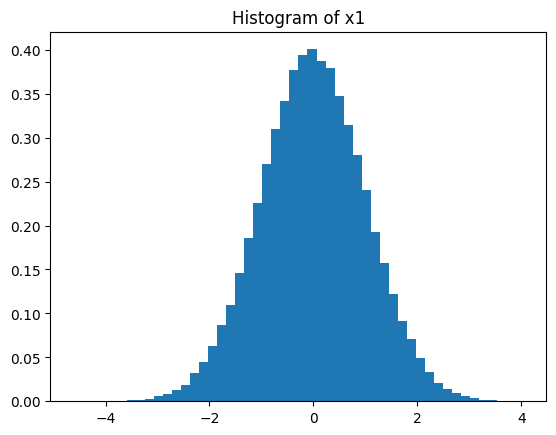

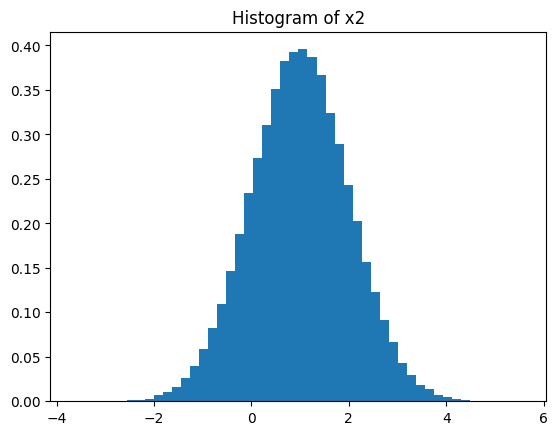

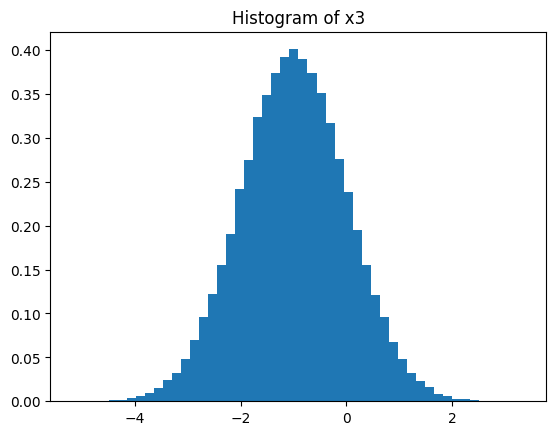

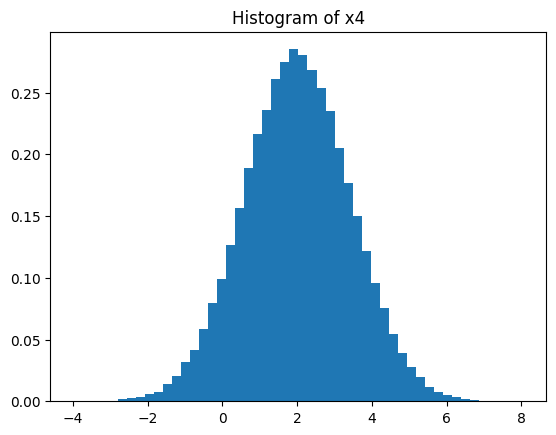

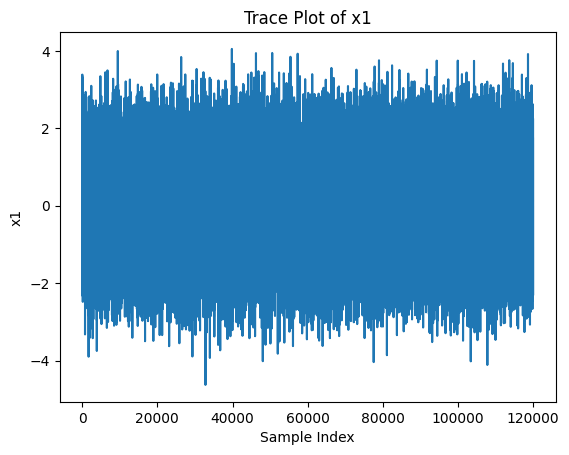

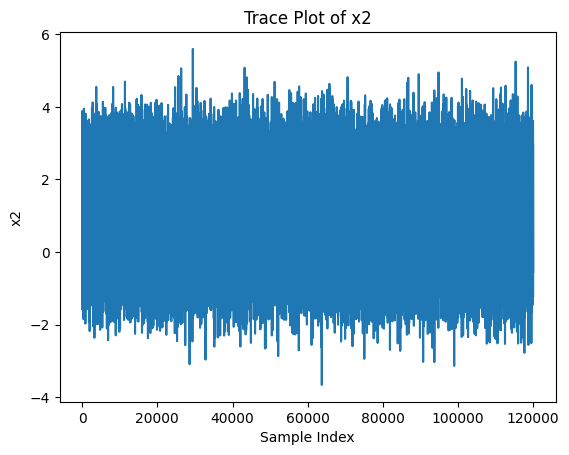

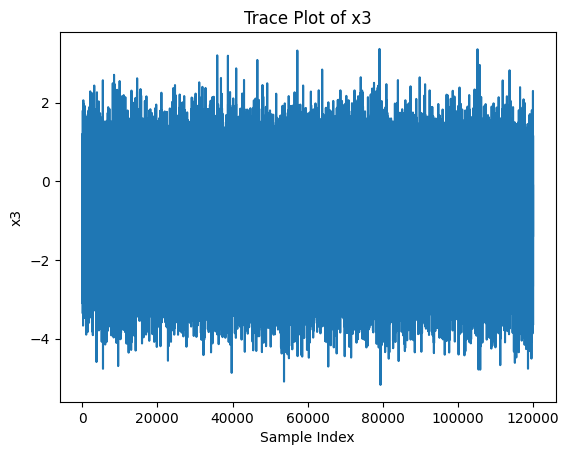

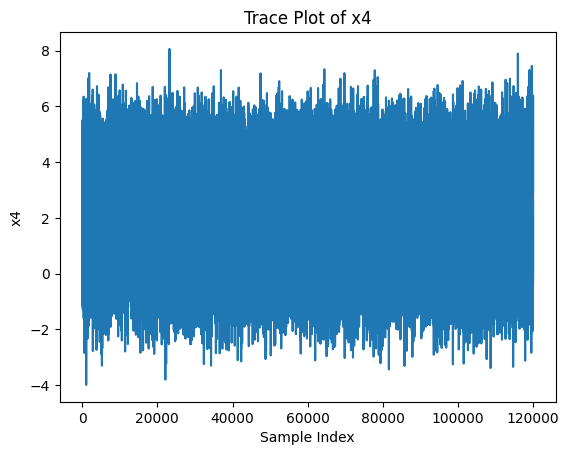

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------
# Function to return conditional mean and variance for x[i]
# given the others in a multivariate normal N(mu, Sigma).
# ------------------------------------------------------------------------
def conditional_params(i, x, mu, Sigma):
    """
    Given a d-dimensional MVN with mean mu and covariance Sigma,
    return the conditional mean and variance for x[i] given x[j != i].

    Parameters:
    -----------
    i : int
        Index of the variable we want to update.
    x : array-like, shape (d,)
        Current values of the entire state vector [x1, x2, ..., xd].
    mu : array-like, shape (d,)
        Mean of the MVN distribution.
    Sigma : array-like, shape (d, d)
        Covariance matrix of the MVN distribution.

    Returns:
    --------
    cond_mean : float
        Conditional mean of x[i] given the other coordinates.
    cond_var : float
        Conditional variance of x[i] given the other coordinates.
    """
    d = len(mu)
    sub_idx = [j for j in range(d) if j != i]  # indices except i

    # Partition the covariance matrix
    Sigma_ii = Sigma[i, i]  # scalar
    Sigma_i_sub = Sigma[i, sub_idx]  # row i, columns != i
    Sigma_sub_i = Sigma[sub_idx, i]  # row != i, column i
    Sigma_sub_sub = Sigma[sub_idx][:, sub_idx]  # submatrix

    inv_sub = np.linalg.inv(Sigma_sub_sub)

    # Conditional mean
    diff = x[sub_idx] - mu[sub_idx]
    cond_mean = mu[i] + Sigma_i_sub @ inv_sub @ diff

    # Conditional variance
    cond_var = Sigma_ii - Sigma_i_sub @ inv_sub @ Sigma_sub_i

    return cond_mean, cond_var

# ------------------------------------------------------------------------
# Main: 4D MVN with mean & covariance
# ------------------------------------------------------------------------
np.random.seed(42)

# Mean vector
mu = np.array([0.0, 1.0, -1.0, 2.0])

# Covariance matrix
Sigma = np.array([
    [1.0,  0.5,  0.0,  0.0],
    [0.5,  1.0,  0.0,  0.0],
    [0.0,  0.0,  1.0,  0.8],
    [0.0,  0.0,  0.8,  2.0]
])

# Number of iterations and burn-in (adjusted to be larger)
iterations = 200000  # e.g., 200K total iterations
burn_in = 80000      # e.g., 80K burn-in

# Initialize x = [x1, x2, x3, x4]
x = np.zeros(4, dtype=float)

# Lists to store samples
samples_x1 = []
samples_x2 = []
samples_x3 = []
samples_x4 = []

for it in range(iterations):
    # We update each coordinate in turn
    for i in range(4):
        cm, cv = conditional_params(i, x, mu, Sigma)
        x[i] = np.random.normal(loc=cm, scale=np.sqrt(cv))

    # Only store samples after burn-in
    if it >= burn_in:
        samples_x1.append(x[0])
        samples_x2.append(x[1])
        samples_x3.append(x[2])
        samples_x4.append(x[3])

samples_x1 = np.array(samples_x1)
samples_x2 = np.array(samples_x2)
samples_x3 = np.array(samples_x3)
samples_x4 = np.array(samples_x4)

# ------------------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------------------
print("Final x state:", x)
print("\nSample means:")
print("mean(x1) =", np.mean(samples_x1))
print("mean(x2) =", np.mean(samples_x2))
print("mean(x3) =", np.mean(samples_x3))
print("mean(x4) =", np.mean(samples_x4))

print("\nSample variances:")
print("var(x1) =", np.var(samples_x1))
print("var(x2) =", np.var(samples_x2))
print("var(x3) =", np.var(samples_x3))
print("var(x4) =", np.var(samples_x4))

# Empirical correlation matrix
all_samples = np.vstack([samples_x1, samples_x2, samples_x3, samples_x4])
corr_matrix = np.corrcoef(all_samples)
print("\nEmpirical correlation matrix:\n", corr_matrix)

# ------------------------------------------------------------------------
# Histograms
# ------------------------------------------------------------------------
plt.hist(samples_x1, bins=50, density=True)
plt.title("Histogram of x1")
plt.show()

plt.hist(samples_x2, bins=50, density=True)
plt.title("Histogram of x2")
plt.show()

plt.hist(samples_x3, bins=50, density=True)
plt.title("Histogram of x3")
plt.show()

plt.hist(samples_x4, bins=50, density=True)
plt.title("Histogram of x4")
plt.show()

# ------------------------------------------------------------------------
# Trace plots
# ------------------------------------------------------------------------
plt.plot(samples_x1)
plt.title("Trace Plot of x1")
plt.xlabel("Sample Index")
plt.ylabel("x1")
plt.show()

plt.plot(samples_x2)
plt.title("Trace Plot of x2")
plt.xlabel("Sample Index")
plt.ylabel("x2")
plt.show()

plt.plot(samples_x3)
plt.title("Trace Plot of x3")
plt.xlabel("Sample Index")
plt.ylabel("x3")
plt.show()

plt.plot(samples_x4)
plt.title("Trace Plot of x4")
plt.xlabel("Sample Index")
plt.ylabel("x4")
plt.show()

#Questions

1. Describe how Gibbs sampling algorithm works. What are its main steps, and what kind of problems is it usually applied to?

2. Why, in Gibbs Sampling, do we examine the evolution of only one variable in the vector space while treating the other variables as conditioning values (their most recent values)? What advantages does this offer compared to direct sampling from the full joint distribution?

3. Mention two factors that may slow down or prevent convergence of the chain. What possible improvements (or variants of Gibbs Sampling) can be used to address such problems?

4. Mention any convergence criteria for the Gibbs sampling procedure, without performing any specific calculations.

**Describe how Gibbs sampling algorithm works. What are its main steps, and what kind of problems is it usually applied to?**

Gibbs sampling is an iterative Monte Carlo method that generates samples from a multivariate distribution by updating one variable at a time from its conditional distribution given the current values of the others. In this Python code, the target distribution is a 4-dimensional Gaussian with mean vector **mu** and covariance matrix **Sigma**. The algorithm starts from an initial vector, computes the conditional mean and variance for each coordinate using the function **conditional_params**, and then draws a new value from the corresponding normal distribution. This process is repeated for many iterations, and the first part of the chain is discarded as burn-in. The remaining samples are used to estimate the mean, variance, correlation matrix, and to produce histograms and trace plots. This method is usually applied to problems where direct sampling from a joint distribution is hard, but sampling from the conditional distributions is easy, such as multivariate Gaussian and Bayesian MCMC problems.

**Why, in Gibbs Sampling, do we examine the evolution of only one variable in the vector space while treating the other variables as conditioning values (their most recent values)? What advantages does this offer compared to direct sampling from the full joint distribution?**

In Gibbs Sampling, we update only one variable at a time while keeping the others fixed at their most recent values because this reduces a difficult multidimensional sampling problem to a much simpler one-dimensional conditional sampling problem. In the Python code, each coordinate of the 4-dimensional Gaussian vector is updated from its conditional normal distribution, whose mean and variance are computed from the current values of the other coordinates. Using the most recent values allows the Markov chain to move consistently toward the target distribution. The main advantage is that Gibbs Sampling replaces one difficult high-dimensional sampling problem with a sequence of much easier low-dimensional ones. Instead of sampling the whole vector from the full joint distribution at once, we sample one variable from its conditional distribution, which is often simple and known explicitly.


**Mention two factors that may slow down or prevent convergence of the chain. What possible improvements (or variants of Gibbs Sampling) can be used to address such problems?**

Gibbs Sampling may converge slowly because it starts from an arbitrary initial state and because it produces correlated trajectories, especially when the variables are dependent. In this Python exercise, this is reflected by the initial vector $x = np.zeros(4)$ and by the correlations in the covariance matrix $Sigma$, which can make mixing slower. Somw practical improvements are to use more iterations, larger burn-in, a better starting point, and simulated annealing / cooling steps.

**Mention any convergence criteria for the Gibbs sampling procedure, without performing any specific calculations.**

Gibbs Sampling is considered to have converged when the Markov chain reaches its equilibrium distribution. In this exercise, this can be checked qualitatively, without calculations, by inspecting the trace plots and histograms. After burn-in, the trace plots of x1, x2, x3, x4 should fluctuate around stable levels with no systematic drift, and the histograms should have a stable Gaussian-like shape. Based on produced plots, these conditions seem to hold, so the chain appears to have converged.